# OBJECTIVE
To classify a sentence or tweet into


*  negative
*  neutral
*  positive
  





In [42]:
#transformers
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification


#torch (runs the neural network)
import torch


#numpy
import numpy as np

In [4]:
#scipy(convert raw prediction values into probabilities)
from scipy.special import softmax

In [5]:
def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

In [6]:
#AutoConfig
from transformers import AutoConfig

In [7]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [43]:

from transformers import AutoConfig

config = AutoConfig.from_pretrained(MODEL)

In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(MODEL)

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
#import libraries
import numpy as np
from scipy.special import softmax

In [11]:
#Preprocessing Function
def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

In [12]:
text = "I like machine learning."
text = preprocess(text)

In [13]:
#convert text into token
encoded_input = tokenizer(text, return_tensors='pt')

In [14]:
#make prediction
output = model(**encoded_input)
scores = output[0][0].detach().numpy()
scores = softmax(scores)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

In [15]:
#result
ranking = np.argsort(scores)
ranking = ranking[::-1]

for i in range(scores.shape[0]):
    label = config.id2label[ranking[i]]
    score = scores[ranking[i]]
    print(f"{label}: {score:.4f}")

positive: 0.9538
neutral: 0.0429
negative: 0.0033


In [16]:
#uploading dataset
from google.colab import files

uploaded = files.upload()

Saving custom_social_media_sentiment_dataset_600.xlsx to custom_social_media_sentiment_dataset_600.xlsx


In [22]:
import pandas as pd

df = pd.read_excel("/content/custom_social_media_sentiment_dataset_600.xlsx")

df.head()


,ID,Text,Sentiment,Label
0,1,"Overall, The AI model gave accurate results th...",Positive,2
1,2,I'm very satisfied because The package was dam...,Positive,2
2,3,I really enjoyed: The model is being evaluated...,Positive,2
3,4,"Overall, The app works flawlessly it was excel...",Positive,2
4,5,I'm very satisfied because The bank queue was ...,Positive,2


In [24]:
#check dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         600 non-null    int64 
 1   Text       600 non-null    object
 2   Sentiment  600 non-null    object
 3   Label      600 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 18.9+ KB


In [25]:
#dataset shape
print(df.shape)

(600, 4)


In [26]:
#class distribution
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,200
Neutral,200
Negative,200


In [27]:
# predict every sentence
def predict_sentiment(text):

    text = preprocess(text)

    encoded_input = tokenizer(
        text,
        return_tensors="pt"
    )

    output = model(**encoded_input)

    scores = output[0][0].detach().numpy()

    scores = softmax(scores)

    ranking = scores.argsort()[::-1]

    prediction = config.id2label[ranking[0]]

    confidence = scores[ranking[0]]

    return prediction.lower(), confidence

In [28]:
import torch

print(torch.cuda.is_available())

True


In [29]:
import torch

predictions = []
confidence_scores = []

batch_size = 32

texts = df["Text"].tolist()

model.eval()

with torch.no_grad():

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        batch = [preprocess(text) for text in batch]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        output = model(**encoded)

        probs = torch.softmax(output.logits, dim=1)

        conf, pred = torch.max(probs, dim=1)

        predictions.extend(
            [config.id2label[p.item()].lower() for p in pred]
        )

        confidence_scores.extend(conf.tolist())

df["Predicted"] = predictions
df["Confidence"] = confidence_scores

df.head()

,ID,Text,Sentiment,Label,Predicted,Confidence
0,1,"Overall, The AI model gave accurate results th...",Positive,2,positive,0.979859
1,2,I'm very satisfied because The package was dam...,Positive,2,positive,0.950322
2,3,I really enjoyed: The model is being evaluated...,Positive,2,positive,0.988275
3,4,"Overall, The app works flawlessly it was excel...",Positive,2,positive,0.986564
4,5,I'm very satisfied because The bank queue was ...,Positive,2,positive,0.970368


In [30]:
#check prediction
df[["Text", "Sentiment", "Predicted", "Confidence"]].head(20)

,Text,Sentiment,Predicted,Confidence
0,"Overall, The AI model gave accurate results th...",Positive,positive,0.979859
1,I'm very satisfied because The package was dam...,Positive,positive,0.950322
2,I really enjoyed: The model is being evaluated...,Positive,positive,0.988275
3,"Overall, The app works flawlessly it was excel...",Positive,positive,0.986564
4,I'm very satisfied because The bank queue was ...,Positive,positive,0.970368
5,"Overall, The refund is delayed it made my day ...",Positive,positive,0.950852
6,I really enjoyed: The performance was outstand...,Positive,positive,0.988667
7,The assignment was helpful the service was out...,Positive,positive,0.982951
8,I really enjoyed: The exam was difficult the s...,Positive,positive,0.983132
9,The prediction seems incorrect everything work...,Positive,positive,0.445225


In [31]:
#calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    df["Sentiment"].str.lower(),
    df["Predicted"]
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7983


In [32]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(
    df["Sentiment"].str.lower(),
    df["Predicted"]
))

              precision    recall  f1-score   support

    negative       0.81      0.99      0.89       200
     neutral       1.00      0.41      0.59       200
    positive       0.73      0.99      0.84       200

    accuracy                           0.80       600
   macro avg       0.85      0.80      0.77       600
weighted avg       0.85      0.80      0.77       600



In [33]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df["Sentiment"].str.lower(),
    df["Predicted"]
)

print(cm)

[[198   0   2]
 [ 45  83  72]
 [  2   0 198]]


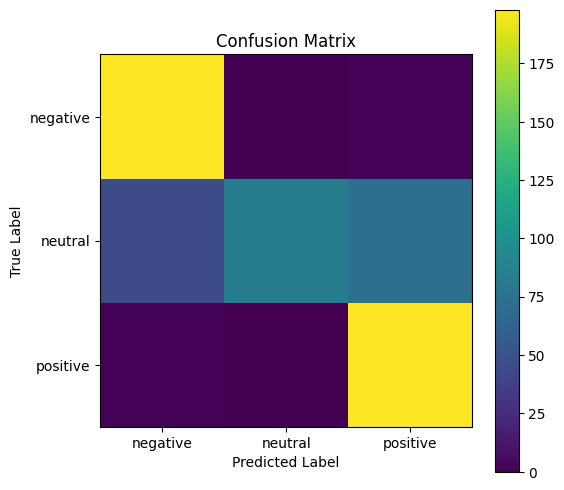

In [34]:
#plot confusion matrix
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["negative", "neutral", "positive"]

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [35]:
# Save prediction results

df.to_excel("Sentiment_Analysis_Results.xlsx", index=False)

print("Results saved successfully!")

Results saved successfully!


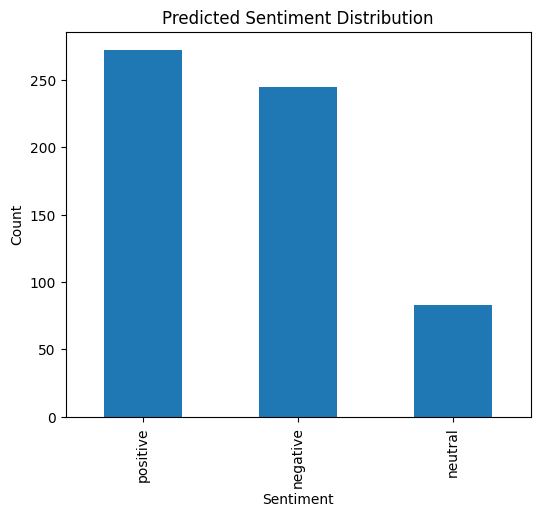

In [36]:
#Visualize Sentiment Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

df["Predicted"].value_counts().plot(
    kind="bar"
)

plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

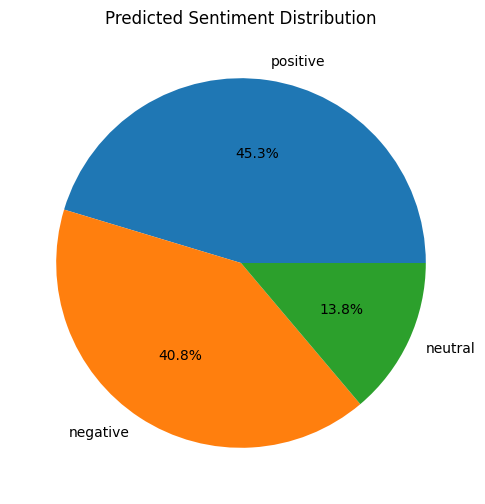

In [37]:
#pie chart
plt.figure(figsize=(6,6))

df["Predicted"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Predicted Sentiment Distribution")

plt.show()

In [38]:
#Show Sample Predictions
df[
    ["Text",
     "Sentiment",
     "Predicted"]
].head(20)

,Text,Sentiment,Predicted
0,"Overall, The AI model gave accurate results th...",Positive,positive
1,I'm very satisfied because The package was dam...,Positive,positive
2,I really enjoyed: The model is being evaluated...,Positive,positive
3,"Overall, The app works flawlessly it was excel...",Positive,positive
4,I'm very satisfied because The bank queue was ...,Positive,positive
5,"Overall, The refund is delayed it made my day ...",Positive,positive
6,I really enjoyed: The performance was outstand...,Positive,positive
7,The assignment was helpful the service was out...,Positive,positive
8,I really enjoyed: The exam was difficult the s...,Positive,positive
9,The prediction seems incorrect everything work...,Positive,positive


In [39]:
#Confusion Matrix as an Image
plt.savefig("Confusion_Matrix.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
#Save Dataset with Predictions
df.to_excel(
    "Prediction_Output.xlsx",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


# Conclusion

This project successfully implemented sentiment analysis using the pretrained CardiffNLP RoBERTa Transformer model. The model classified text into Positive, Neutral, and Negative sentiments using a custom dataset of 600 samples.

The model achieved an overall accuracy of approximately 79.8%, demonstrating strong performance in identifying positive and negative sentiments while highlighting the challenges associated with neutral sentiment classification.

This project showcases the practical application of transformer-based Natural Language Processing for sentiment analysis and can be extended in the future through model fine-tuning, larger datasets, multilingual support, and real-time social media integration.